# 💼 Retail Sales Analysis — Business Owner Checklist

## 🎯 Goal
Understand what drives revenue, customers, and product performance in the business.

---

# 1️⃣ 💰 OVERALL BUSINESS PERFORMANCE

## What I want to know:
- Total revenue generated
- Total number of transactions
- Average transaction value
- Total quantity sold
- Is the business growing or stable?

## Key insight space:
- What does overall performance tell me?

---

# 2️⃣ 🛍️ PRODUCT / CATEGORY PERFORMANCE

## What I want to know:
- Revenue by product category
- Quantity sold per category
- Best performing category
- Worst performing category
- Are a few products dominating revenue?

## Key insight space:
- Which products/categories actually drive the business?

---

# 3️⃣ 👤 CUSTOMER ANALYSIS

## What I want to know:
- Number of unique customers
- Revenue per customer
- Who are the highest spending customers?
- Gender distribution of customers
- Age distribution of customers

## Key insight space:
- Who are my most valuable customers?

---

# 4️⃣ 📦 BUYING BEHAVIOUR

## What I want to know:
- Do customers buy many cheap items or few expensive ones?
- Relationship between quantity and total spending
- Does price affect how much people buy?

## Key insight space:
- How do customers actually behave when buying?

---

# 5️⃣ 🌍 SEGMENT ANALYSIS (Gender / Age / Category)

## What I want to know:
- Sales by Gender × Category
- Which gender spends more overall?
- Which age group spends the most?
- Any strong preference patterns?

## Key insight space:
- Do different groups buy different things?

---

# 6️⃣ 📈 TIME / TREND ANALYSIS (if Date exists)

## What I want to know:
- Sales over time
- Best performing months
- Worst performing months
- Seasonal patterns (if any)

## Key insight space:
- When does the business perform best?

---
Every calculation or graph must answer:
> “What does this mean for the business?”

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


# 💰 1️⃣ Overall Business Performance

## 🟡 Question 1:
What is the total revenue generated by the business?

## 🟡 Question 2:
How many transactions have been made?

## 🟡 Question 3:
What is the average transaction value?

## 🟡 Question 4:
How many total items have been sold?

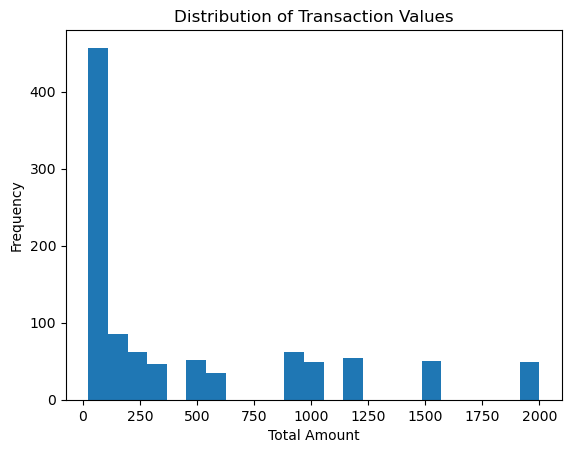

In [3]:
plt.hist(df["Total Amount"], bins=23)
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Values")
plt.show()

In [4]:
total_revenue = df["Total Amount"].sum()
total_items_sold = df["Quantity"].sum()
average_spend_transaction = round(df["Total Amount"].mean(),3)
total_transactions = df["Transaction ID"].nunique()
print(f"""
Total Revenue: {total_revenue}
Total Items Sold: {total_items_sold}
Total Transactions: {total_transactions}
Average Spend per Transaction: {average_spend_transaction}
""")



Total Revenue: 456000
Total Items Sold: 2514
Total Transactions: 1000
Average Spend per Transaction: 456.0



“The business processes a high number of transactions, suggesting strong customer activity, The histogram shows that most purchases are low-value, suggesting the business relies primarily on frequent small transactions rather than high-value sales.”

# 2️⃣ 🛍️ PRODUCT / CATEGORY PERFORMANCE

## What I want to know:
- Revenue by product category?
- Quantity sold per category?
- Best performing category?
- Worst performing category?
- Are a few products dominating revenue?

## Key insight space:
- Which products/categories actually drive the business?

---

In [5]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


C:\Users\Admin\AppData\Local\Temp\ipykernel_10076\637566406.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = catergory, y = total_revenue_catergory,palette="viridis")


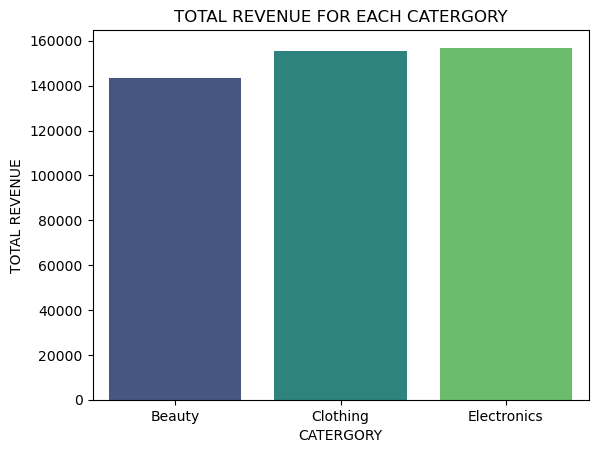

In [6]:
df_reveunue_quantity_catergory = df.groupby("Product Category")[["Total Amount","Quantity"]].sum()
total_revenue_catergory = df_reveunue_quantity_catergory["Total Amount"].values
catergory = df["Product Category"].unique() 

sns.barplot(x = catergory, y = total_revenue_catergory,palette="viridis")
plt.title("TOTAL REVENUE FOR EACH CATERGORY")
plt.ylabel("TOTAL REVENUE")
plt.xlabel("CATERGORY")
plt.show()

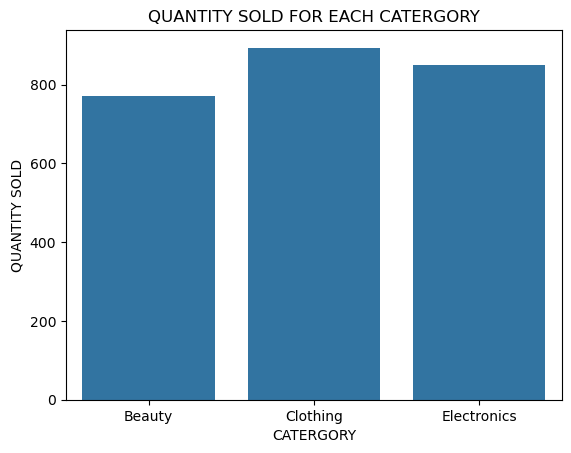

In [7]:
total_quanity_category = df_reveunue_quantity_catergory["Quantity"].values

sns.barplot(x = catergory, y = total_quanity_category, )
plt.title("QUANTITY SOLD FOR EACH CATERGORY")
plt.ylabel("QUANTITY SOLD")
plt.xlabel("CATERGORY")
plt.show()

best performing prodcut is clothing which get the most item solds. However electronic contributed the most of the revenue which shows that electronics has higher revenue per product. In the opposite beuaty seems the least well performed prodcut has it has lowest revenue and sold

# 3️⃣ 👤 CUSTOMER ANALYSIS

## What I want to know:
- Number of unique customers
- Revenue per customer
- Who are the highest spending customers?
- Gender distribution of customers
- Age distribution of customers

## Key insight space:
- Who are my most valuable customers?

---


In [8]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150



number of unquie customer is 1000
revenue per customer on average is 456.0




C:\Users\Admin\AppData\Local\Temp\ipykernel_10076\3295040309.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_10076\3295040309.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


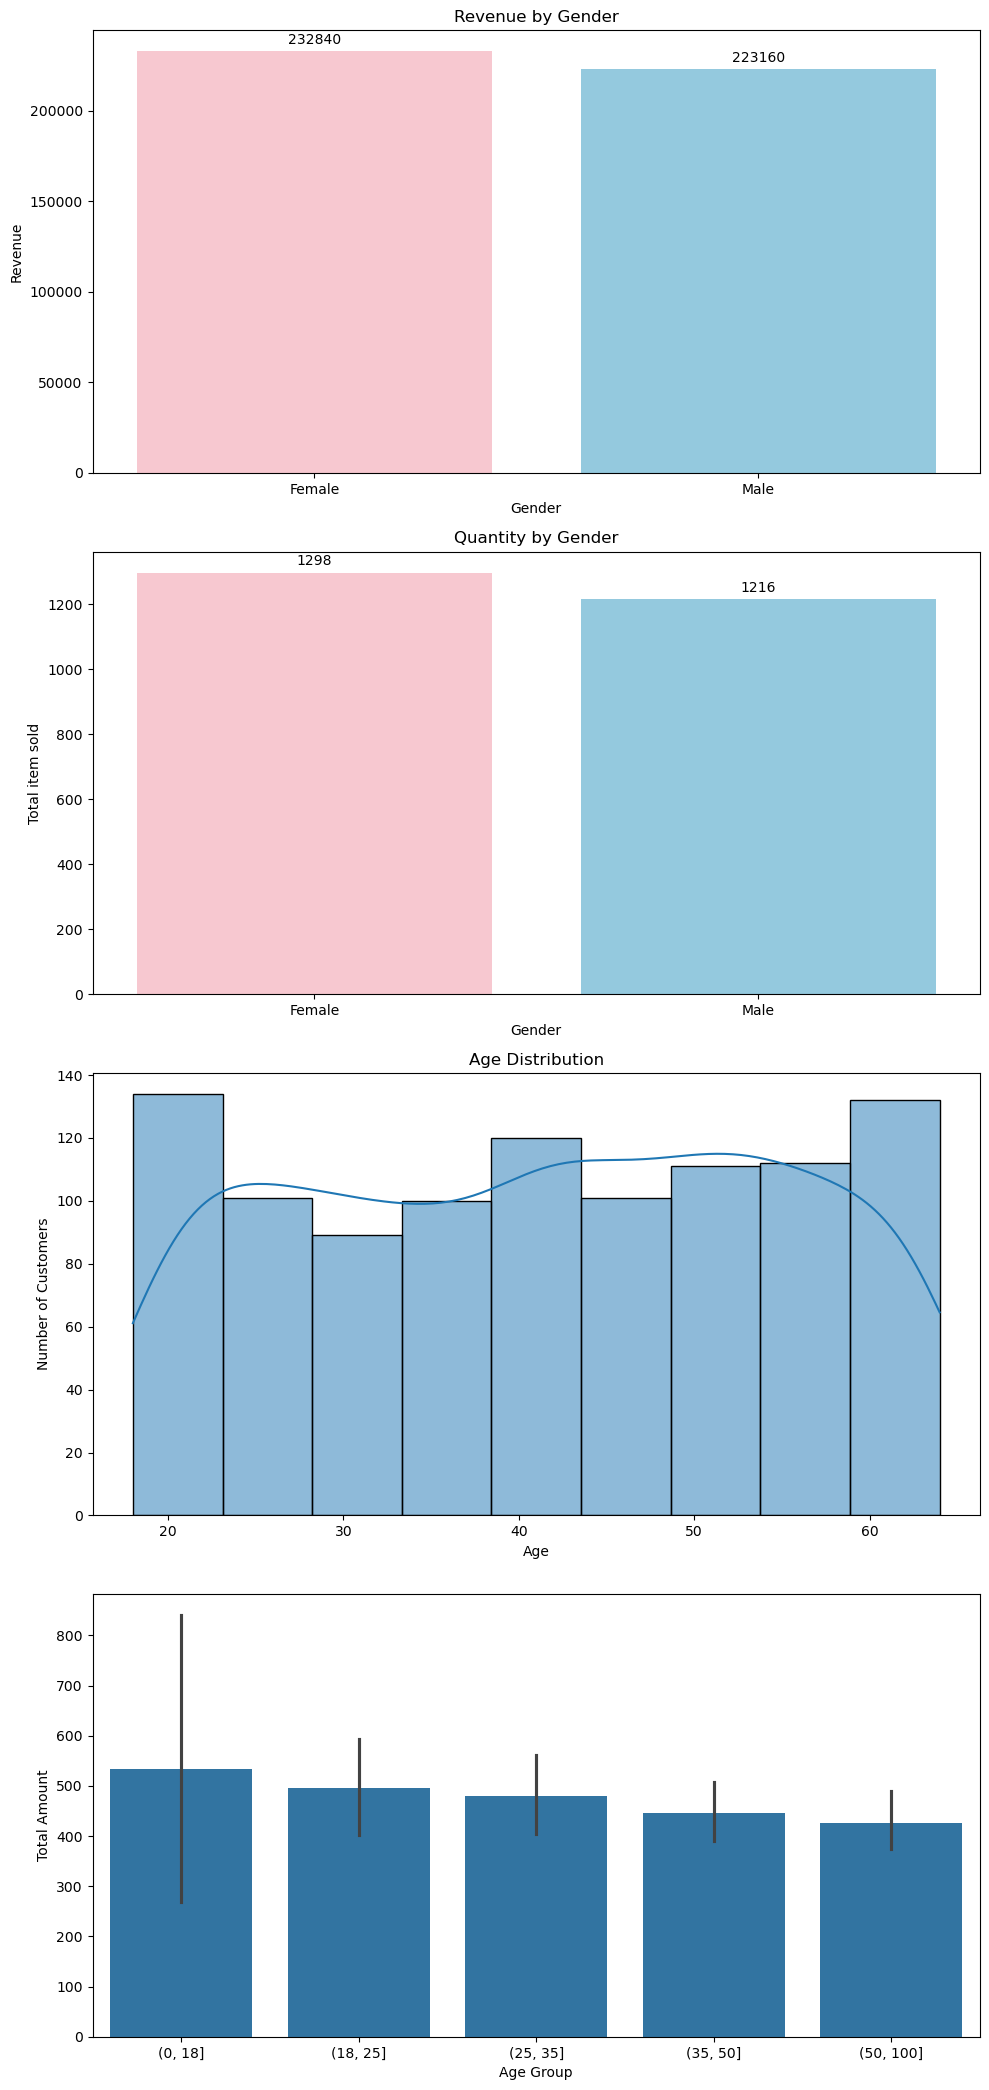

In [9]:
num_unique_customers = df["Customer ID"].nunique()
revenue_per_customer  = df["Total Amount"].mean()

print(f"""
number of unquie customer is {num_unique_customers}
revenue per customer on average is {revenue_per_customer}

""")

df_gender = df.groupby("Gender")[["Total Amount", "Quantity"]].sum()

fig, axes = plt.subplots(4, 1, figsize=(10, 21))
sns.barplot(
    data=df_gender,
    x="Gender",
    y="Total Amount",
    ax=axes[0],
    palette={"Male": "skyblue", "Female": "pink"}
)
axes[0].set_title("Revenue by Gender")
axes[0].set_ylabel("Revenue")

sns.barplot(
    data=df_gender,
    x="Gender",
    y="Quantity",
    ax=axes[1],
    palette={"Male": "skyblue", "Female": "pink"}
)


axes[1].set_title("Quantity by Gender")
axes[1].set_ylabel("Total item sold")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=3)

sns.histplot(data=df, x="Age", binwidth=5, kde=True, ax = axes[2])

axes[2].set_title("Age Distribution")
axes[2].set_ylabel("Number of Customers")
axes[2].set_xlabel("Age")

df["Age Group"] = pd.cut(df["Age"], bins=[0,18,25,35,50,100])

sns.barplot(
    data=df,
    x="Age Group",
    y="Total Amount",
    ax = axes[3]
)
plt.tight_layout()
plt.show()


# 4️⃣ 📦 BUYING BEHAVIOUR

## What I want to know:
- Do customers buy many cheap items or few expensive ones?
- Relationship between quantity and total spending
- Does price affect how much people buy?

## Key insight space:
- How do customers actually behave when buying?

---

In [10]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,"(25, 35]"
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,"(25, 35]"
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,"(35, 50]"
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,"(35, 50]"
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,"(25, 35]"
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,"(50, 100]"
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,"(50, 100]"
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,"(18, 25]"
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,"(35, 50]"


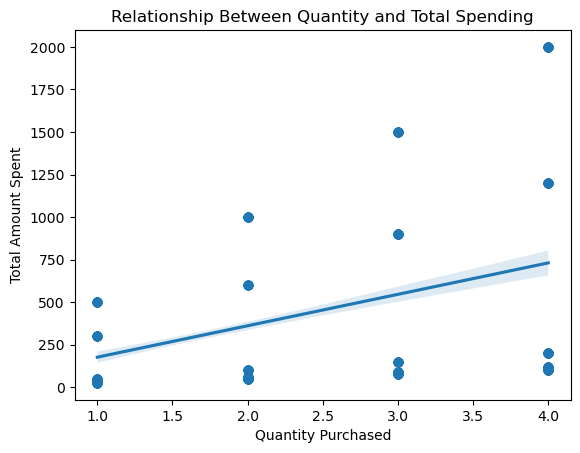

In [11]:
sns.regplot(data=df, x="Quantity", y="Total Amount", scatter_kws={"alpha":0.5})

df["Revenue per Item"] = df["Total Amount"] / df["Quantity"]

plt.title("Relationship Between Quantity and Total Spending")
plt.xlabel("Quantity Purchased")
plt.ylabel("Total Amount Spent")

plt.show()

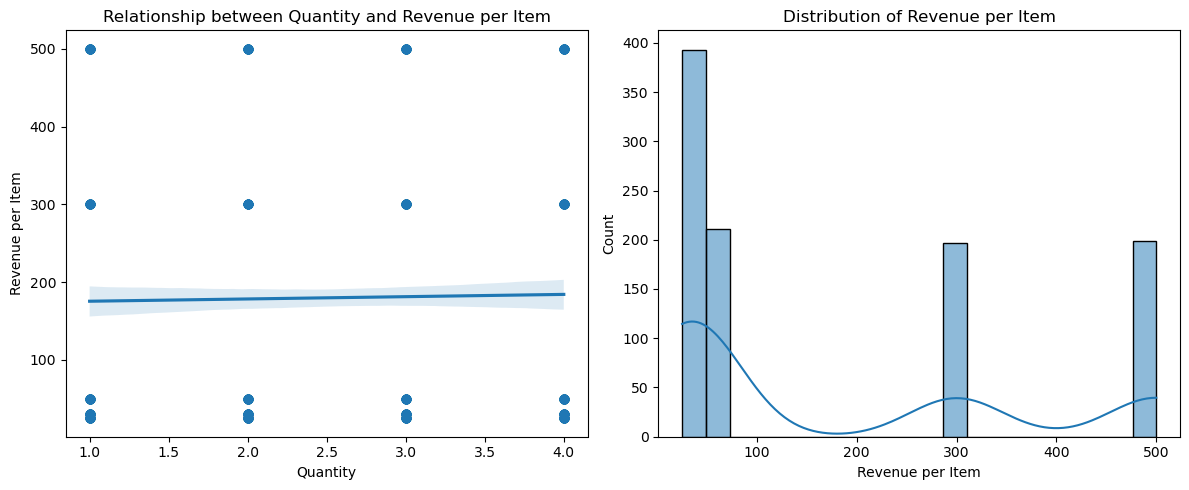

In [12]:
fig_2, axes_2 = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=df, x="Quantity", y="Revenue per Item", ax=axes_2[0])
axes_2[0].set_title("Relationship between Quantity and Revenue per Item")

sns.histplot(df["Revenue per Item"], bins=20, kde=True, ax=axes_2[1])
axes_2[1].set_title("Distribution of Revenue per Item")

plt.tight_layout()
plt.show()

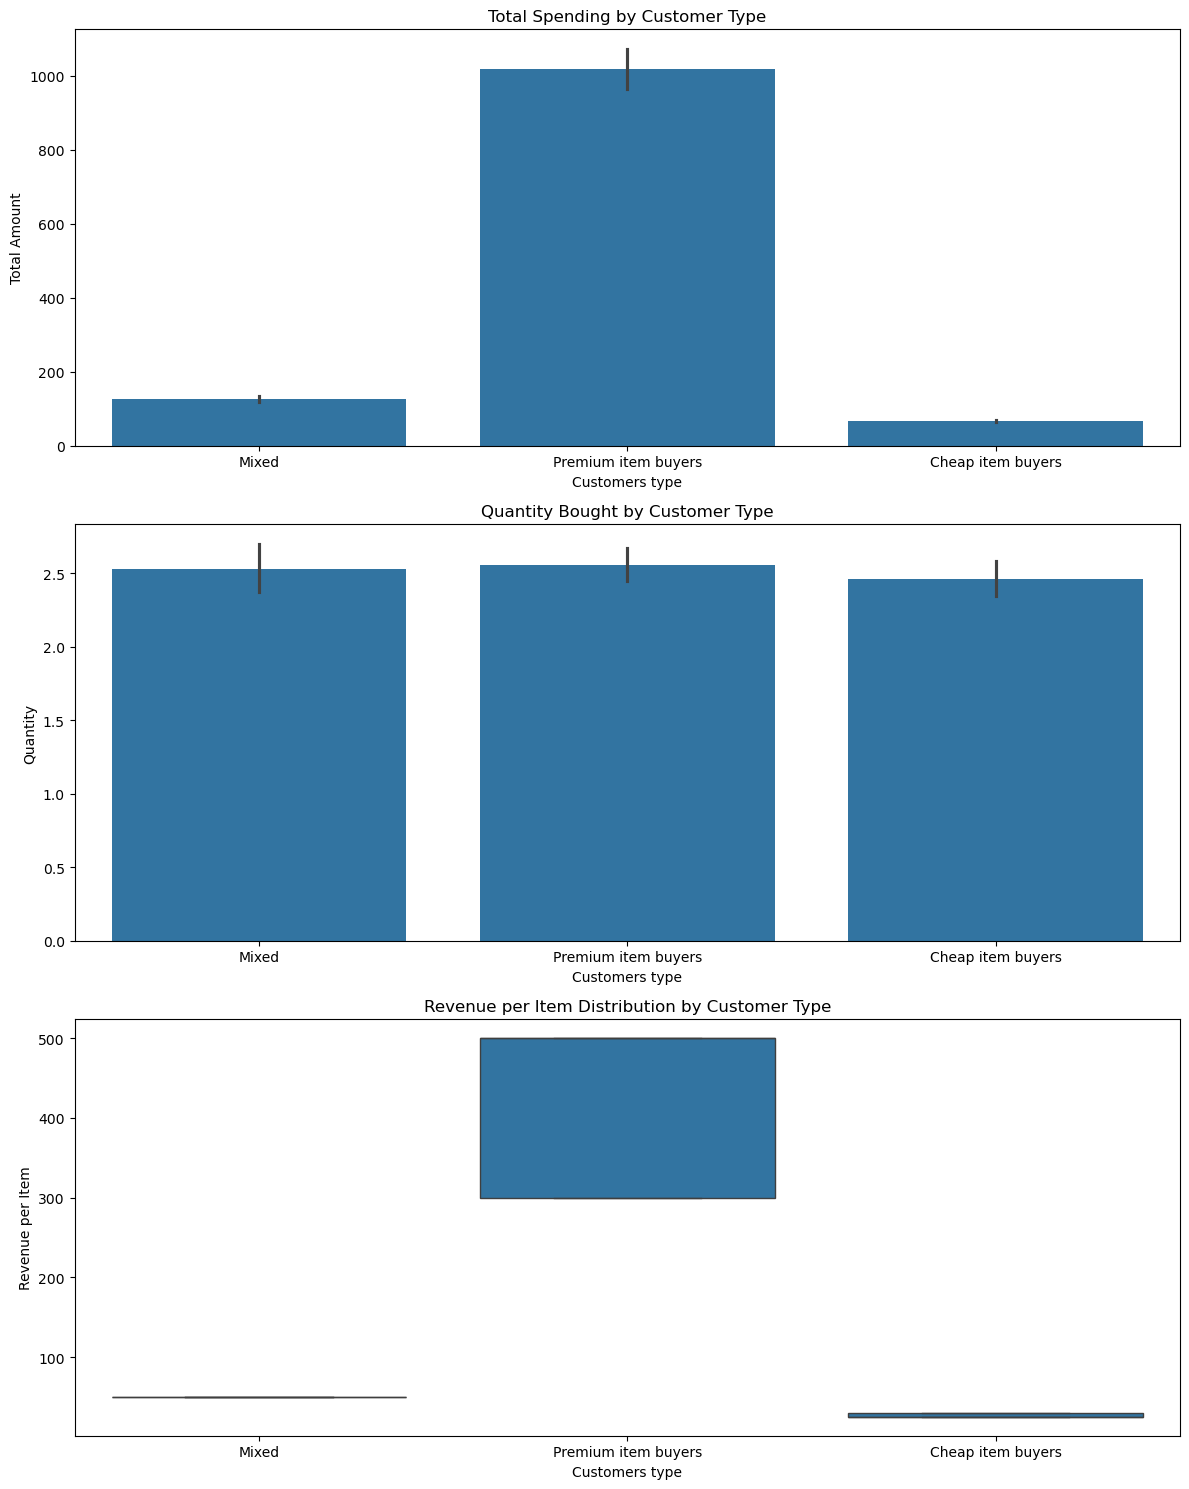

In [13]:
df["Customers type"] = "Mixed"

median_val = df["Revenue per Item"].median()

df.loc[df["Revenue per Item"] < median_val, "Customers type"] = "Cheap item buyers"
df.loc[df["Revenue per Item"] > median_val, "Customers type"] = "Premium item buyers"


fig3, axes3 = plt.subplots(3, 1, figsize=(12, 15))

sns.barplot(data=df, x="Customers type", y="Total Amount", ax=axes3[0])
axes3[0].set_title("Total Spending by Customer Type")

sns.barplot(data=df, x="Customers type", y="Quantity", ax=axes3[1])
axes3[1].set_title("Quantity Bought by Customer Type")

sns.boxplot(data=df, x="Customers type", y="Revenue per Item", ax=axes3[2])
axes3[2].set_title("Revenue per Item Distribution by Customer Type")

plt.tight_layout()
plt.show()

# 5️⃣ 🌍 SEGMENT ANALYSIS (Gender / Age / Category)

## What I want to know:
- Sales by Gender × Category
- Which gender spends more overall?
- Which age group spends the most?
- Any strong preference patterns?

## Key insight space:
- Do different groups buy different things?

---

In [14]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group,Revenue per Item,Customers type
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,"(25, 35]",50.0,Mixed
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,"(25, 35]",500.0,Premium item buyers
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,"(35, 50]",30.0,Cheap item buyers
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,"(35, 50]",500.0,Premium item buyers
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,"(25, 35]",50.0,Mixed
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,"(50, 100]",50.0,Mixed
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,"(50, 100]",30.0,Cheap item buyers
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,"(18, 25]",25.0,Cheap item buyers
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,"(35, 50]",50.0,Mixed


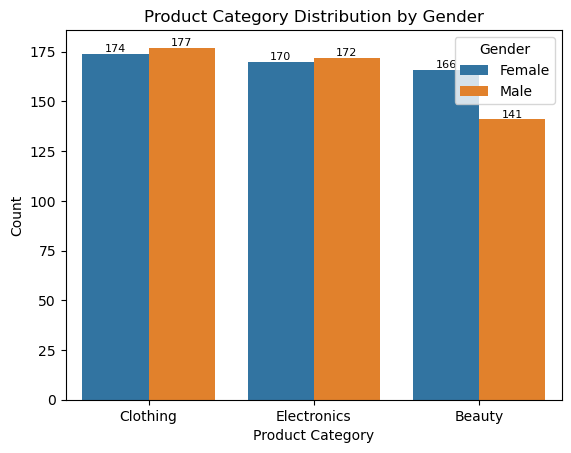

In [15]:
df_gender_producttype = df.groupby("Gender")[["Product Category"]].value_counts()
df_counts = df_gender_producttype.reset_index(name="Count")
ax = sns.barplot(
    data=df_counts,
    x="Product Category",
    y="Count",
    hue="Gender"
)

# 👇 this adds the labels
for container in ax.containers:
    ax.bar_label(container, fontsize=8)  # smaller text

plt.title("Product Category Distribution by Gender")
plt.show()

# 6️⃣ 📈 TIME / TREND ANALYSIS (if Date exists)

## What I want to know:
- Sales over time
- Best performing months
- Worst performing months
- Seasonal patterns (if any)

## Key insight space:
- When does the business perform best?


In [16]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group,Revenue per Item,Customers type
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,"(25, 35]",50.0,Mixed
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,"(25, 35]",500.0,Premium item buyers
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,"(35, 50]",30.0,Cheap item buyers
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,"(35, 50]",500.0,Premium item buyers
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,"(25, 35]",50.0,Mixed
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,"(50, 100]",50.0,Mixed
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,"(50, 100]",30.0,Cheap item buyers
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,"(18, 25]",25.0,Cheap item buyers
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,"(35, 50]",50.0,Mixed


In [28]:
# this convert date columns into date time data type
df["Date"] = pd.to_datetime(df["Date"])


# this make sure its in month order
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
# 1. Convert the 'Date' column to actual datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 2. Create the 'Month' column (e.g., 'January', 'February')
df['Month'] = df['Date'].dt.month_name()
df['Month'] = pd.Categorical(df['Date'].dt.month_name(), categories=month_order, ordered=True)



C:\Users\Admin\AppData\Local\Temp\ipykernel_10076\681328298.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_month_revenue_quantity = df.groupby("Month")[["Total Amount", "Quantity"]].sum()


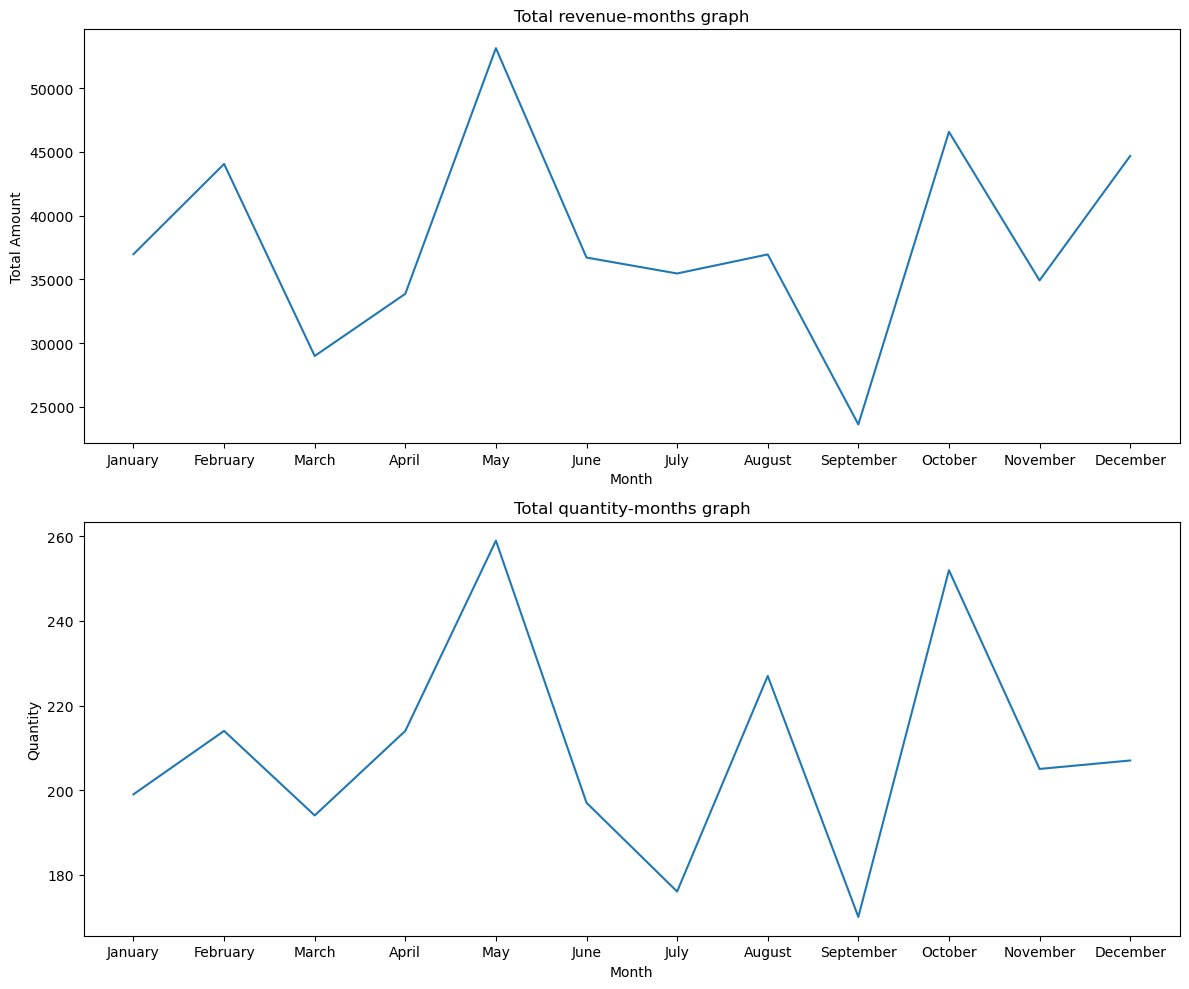

In [33]:
df_month_revenue_quantity = df.groupby("Month")[["Total Amount", "Quantity"]].sum()

fig4, ax4 = plt.subplots(2, 1, figsize=(12, 10))

sns.lineplot(data=df_month_revenue_quantity,
             x="Month",
             y="Total Amount",
             ax=ax4[0])
sns.lineplot(data = df_month_revenue_quantity,x = "Month", y = "Quantity", ax = ax4[1])
ax4[0].set_title("Total revenue-months graph")
ax4[1].set_title("Total quantity-months graph")
plt.tight_layout()
plt.show()



In [ ]:
df_month_revenue_quantity